<a href="https://colab.research.google.com/github/sarnika09-cell/MoodNet_Sentiment_Analysis/blob/main/MoodNet_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving sentiment140.csv to sentiment140 (1).csv


In [3]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
df = pd.read_csv("sentiment140.csv", encoding='latin-1', header=None)

df.columns = ['label', 'id', 'date', 'query', 'user', 'text']

df = df[['label', 'text']]

df.head()

,label,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [5]:
df = df[df['label'] != 2]

In [6]:
df['label'] = df['label'].replace({0:0, 4:1})

In [7]:
df = df.sample(20000, random_state=42)

In [8]:
print(df['label'].value_counts())

label
1    10058
0     9942
Name: count, dtype: int64


In [9]:
import re

def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^A-Za-z]', ' ', text)
    text = text.lower()
    return text

df['text'] = df['text'].apply(clean_text)

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X, maxlen=100)

y = df['label']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout

model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128))  # increased
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(32))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [16]:
model.fit(X_train, y_train, epochs=8, batch_size=32)

Epoch 1/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step - accuracy: 0.9447 - loss: 0.1322
Epoch 2/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 89ms/step - accuracy: 0.9528 - loss: 0.1141
Epoch 3/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 92ms/step - accuracy: 0.9629 - loss: 0.0898
Epoch 4/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - accuracy: 0.9682 - loss: 0.0774
Epoch 5/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 91ms/step - accuracy: 0.9710 - loss: 0.0719
Epoch 6/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 95ms/step - accuracy: 0.9784 - loss: 0.0524
Epoch 7/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - accuracy: 0.9799 - loss: 0.0493
Epoch 8/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 93ms/step - accuracy: 0.9826 - loss: 0.0415


In [17]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step
Accuracy: 0.71675
              precision    recall  f1-score   support

           0       0.71      0.72      0.72      1988
           1       0.72      0.72      0.72      2012

    accuracy                           0.72      4000
   macro avg       0.72      0.72      0.72      4000
weighted avg       0.72      0.72      0.72      4000



In [20]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 113ms/step - accuracy: 0.9827 - loss: 0.0433
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 104ms/step - accuracy: 0.9827 - loss: 0.0422
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 107ms/step - accuracy: 0.9864 - loss: 0.0317
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 95ms/step - accuracy: 0.9878 - loss: 0.0301
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 92ms/step - accuracy: 0.9861 - loss: 0.0323


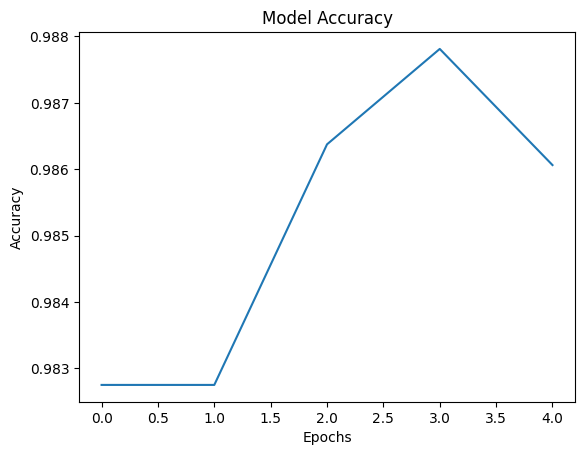

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [27]:
from sklearn.metrics import accuracy_score

# Predict using LSTM
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

# Store accuracy
lstm_accuracy = accuracy_score(y_test, y_pred)

print("LSTM Accuracy:", lstm_accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step
LSTM Accuracy: 0.7165


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df['text'])

# Split
from sklearn.model_selection import train_test_split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Train LR
lr = LogisticRegression()
lr.fit(X_train_lr, y_train_lr)

# Predict
pred_lr = lr.predict(X_test_lr)

# Store accuracy
lr_accuracy = accuracy_score(y_test_lr, pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.76175


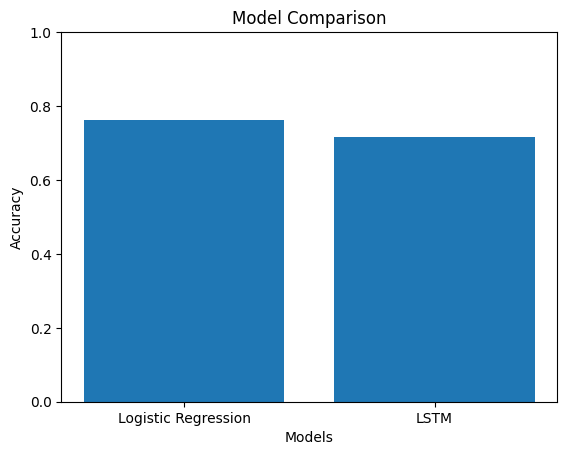

In [29]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'LSTM']
accuracy = [lr_accuracy, lstm_accuracy]

plt.bar(models, accuracy)
plt.ylim(0, 1)
plt.title('Model Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

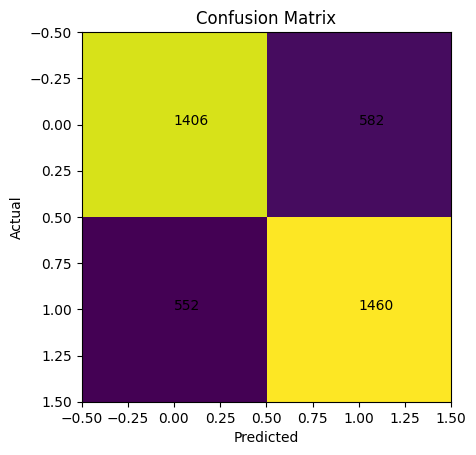

In [30]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j])

plt.show()